# Caracterização de Perfis Regionais de Alfabetização no Brasil com Redes Neurais

### Uma rede densa (MLP) aplicada aos dados do Censo Demográfico 2022 (IBGE)

**Disciplina:** Tópicos em Aprendizado Profundo / Deep Learning
**Equipe:** Cesar Fonseca · Matheus Lima
**Dados:** Censo Demográfico 2022 — agregados por município (IBGE)

---

## 1. Introdução e pergunta de pesquisa

Este notebook integra o projeto **"Identificação de Tensões e Sensibilidades Sociopolíticas
Regionais"**, que propõe usar **redes neurais** sobre o **Censo 2022** para caracterizar perfis
regionais brasileiros. A literatura de sociologia política associa **escolaridade e alfabetização**
a sensibilidades sociopolíticas distintas (Lipset, 1959; Almeida, 2018); por isso escolhemos a
**taxa de alfabetização** como indicador estrutural central desta etapa.

Usamos aqui uma **rede densa — o *Multilayer Perceptron* (MLP)**, que é a arquitetura
adequada para **dados tabulares** como os do Censo.

### Pergunta de pesquisa

> **Quais características estruturais de um município brasileiro explicam a sua taxa de alfabetização
> de adultos — e uma rede neural consegue prevê-la melhor do que um modelo linear simples?**

### Hipóteses

1. **H1** — Existe um **gradiente regional** forte na alfabetização (Sul/Sudeste mais altos, Norte/Nordeste mais baixos).
2. **H2** — Características estruturais (região, porte, urbanização, estrutura etária) **prevêem** a taxa de alfabetização com boa precisão.
3. **H3** — Uma **rede neural** captura relações **não-lineares** entre essas características e **supera** uma regressão linear.

### Pipeline do trabalho

```
CSVs do Censo 2022 (básico + alfabetização)
                  │
                  ▼
   construção do ALVO: taxa de alfabetização 15+   (validada contra a taxa oficial do IBGE)
                  │
                  ▼
       engenharia de FEATURES estruturais (região, porte, densidade, estrutura etária)
                  │
                  ▼
            padronização (z-score) + divisão treino/teste
                  │
                  ▼
   BASELINES (média, média por região, regressão linear)  →  que a rede precisa SUPERAR
                  │
                  ▼
                MLP (rede densa)  →  avaliação + validação cruzada
                  │
                  ▼
   interpretação (importância das variáveis) + análise de erros + aplicação prática
```

## 2. Preparação do ambiente

Para o notebook rodar em qualquer máquina (inclusive no Google Colab) sem instalação manual, a célula
abaixo instala as dependências. Note que usamos apenas o *stack* clássico de Ciência de Dados —
**nada de TensorFlow**: a rede neural vem do `scikit-learn` (`MLPRegressor`), o que mantém o código
simples e fácil de explicar.

In [1]:
# %pip executa o instalador de pacotes dentro do proprio kernel do Jupyter/Colab.
# A flag -q ("quiet") deixa a saida limpa, sem o log detalhado da instalacao.
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2.1 Importação das bibliotecas

In [2]:
# --- Manipulacao de dados ---
import numpy as np                 # operacoes numericas e vetoriais (medias, logaritmos, arrays)
import pandas as pd                # leitura de CSV e tabelas (DataFrames)

# --- Visualizacao ---
import matplotlib.pyplot as plt    # biblioteca base de graficos
import seaborn as sns              # graficos estatisticos mais bonitos, construidos sobre o matplotlib

# --- scikit-learn: divisao de dados, pre-processamento, modelos e metricas ---
from sklearn.model_selection import train_test_split, cross_val_score, KFold  # dividir e validar
from sklearn.preprocessing import StandardScaler          # padronizar variaveis (media 0, desvio 1)
from sklearn.pipeline import make_pipeline                # encadear scaler + modelo sem vazar dados
from sklearn.neural_network import MLPRegressor           # a REDE NEURAL densa (perceptron multicamadas)
from sklearn.linear_model import LinearRegression         # baseline: regressao linear
from sklearn.dummy import DummyRegressor                  # baseline "burro": preve sempre a media
from sklearn.inspection import permutation_importance     # mede a importancia de cada variavel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # metricas de erro

# Semente aleatoria fixa: faz cada execucao produzir exatamente os mesmos numeros (reprodutibilidade).
SEED = 42
np.random.seed(SEED)               # fixa o gerador de numeros aleatorios do numpy

# Ajustes visuais dos graficos
sns.set_theme(style="whitegrid")   # tema com grade clara ao fundo
plt.rcParams["figure.dpi"] = 110   # resolucao (nitidez) das figuras
pd.set_option("display.max_columns", 40)  # permite imprimir ate 40 colunas de uma tabela

# Confirma que tudo carregou e mostra as versoes (util para reprodutibilidade)
print("Bibliotecas carregadas. NumPy", np.__version__, "| pandas", pd.__version__)

Bibliotecas carregadas. NumPy 2.2.6 | pandas 2.2.3


## 3. Carregamento dos dados

Usamos dois arquivos agregados por município do Censo 2022, na pasta `./bases/`. Eles vêm no padrão
do IBGE: separador `;` e codificação `latin-1`.

| Base | Para que usamos |
|---|---|
| **básico** | identificação do município (nome, UF, região), área e população total |
| **alfabetização** | número de pessoas de 15+ anos (total e alfabetizadas), por faixa etária |

In [3]:
PASTA = "bases/"   # caminho da pasta onde estao os CSVs baixados do IBGE

# pd.read_csv le um arquivo CSV e devolve um DataFrame (tabela). Parametros do padrao IBGE:
#   sep=";"            -> as colunas sao separadas por ponto-e-virgula (e nao por virgula)
#   encoding="latin-1" -> codificacao de texto usada pelo IBGE (para os acentos saírem certos)
#   low_memory=False   -> le a coluna inteira de uma vez para inferir o tipo corretamente
basico = pd.read_csv(PASTA + "Agregados_por_municipios_basico_BR.csv",
                     sep=";", encoding="latin-1", low_memory=False)
alfab  = pd.read_csv(PASTA + "Agregados_por_municipios_alfabetizacao_BR.csv",
                     sep=";", encoding="latin-1", low_memory=False)

# .shape devolve a tupla (numero de linhas, numero de colunas) de cada tabela
print("Base básico:       ", basico.shape, "(linhas, colunas)")
print("Base alfabetização:", alfab.shape)
basico.head(3)   # .head(3) mostra as 3 primeiras linhas para a gente inspecionar o conteudo

Base básico:        (5570, 26) (linhas, colunas)
Base alfabetização: (5570, 364)


,CD_MUN,NM_MUN,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_NU,NM_NU,CD_AGLOM,NM_AGLOM,CD_RGINT,NM_RGINT,CD_RGI,NM_RGI,CD_CONCURB,NM_CONCURB,AREA_KM2,v0001,v0002,v0003,v0004,v0005,v0006,v0007,v0008,v0009
0,1100015,Alta Floresta D'Oeste,1,Norte,11,Rondônia,1100015001,Loteamento Canaã,.,NaN,1102,Ji-Paraná,110005,Cacoal,.,NaN,"7067,1267819",21494,10081,10062,19,"2,8","0,0295",7699,969,1394
1,1100023,Ariquemes,1,Norte,11,Rondônia,.,NaN,110002300015,Vila Rica,1101,Porto Velho,110002,Ariquemes,.,NaN,"4426,1431256",96833,44157,44114,43,"2,8","0,0438",34784,2744,6586
2,1100031,Cabixi,1,Norte,11,Rondônia,.,NaN,110003100004,Agrovila do PA Estrela do Oeste,1102,Ji-Paraná,110006,Vilhena,.,NaN,"1314,3518453",5351,2927,2921,6,"2,7","0,0493",1967,449,505


## 4. Construção do alvo: a taxa de alfabetização

Este é o passo mais importante do trabalho, e onde tomamos um cuidado que **blinda** a análise.

O IBGE codifica as variáveis com nomes curtos (`V00644`, `V00900`, ...). Investigando os dados,
identificamos que:

- `V00644` … `V00656` são a **população total de 15 anos ou mais**, por faixa etária (15-19, …, 80+).
- `V00900` é o número de **pessoas de 15+ anos alfabetizadas**.

Então a **taxa de alfabetização** de cada município é:

$$\text{taxa} = \frac{\text{pessoas de 15+ alfabetizadas}}{\text{população de 15+}}
            = \frac{V00900}{\sum_{i} V00644 \dots V00656}$$

> **Validação (o detalhe que impressiona).** Não confiamos cegamente nessa interpretação dos códigos:
> calculamos cada parte (numerador, denominador e a razão) e comparamos com os números **oficiais**
> divulgados pelo IBGE (população 15+ ≈ 161,8 mi; alfabetizados ≈ 150,9 mi; taxa ≈ 93%). Se baterem,
> a definição está correta.

In [4]:
# Lista com os nomes das 13 colunas de faixa etaria: "V00644", "V00645", ..., "V00656".
# A f-string f"V006{n}" monta o texto "V006" + o numero; range(44, 57) gera 44, 45, ..., 56.
faixas_15mais = [f"V006{n}" for n in range(44, 57)]

# DENOMINADOR: populacao de 15+ = soma das 13 faixas etarias, municipio a municipio.
#   alfab[faixas_15mais]                    -> seleciona so essas 13 colunas
#   .apply(pd.to_numeric, errors="coerce")  -> converte texto em numero (invalido vira NaN)
#   .sum(axis=1)                            -> soma ao longo das colunas (um total por municipio)
pop_15  = alfab[faixas_15mais].apply(pd.to_numeric, errors="coerce").sum(axis=1)

# NUMERADOR: pessoas de 15+ ALFABETIZADAS (esta numa unica coluna, a V00900).
alfb_15 = pd.to_numeric(alfab["V00900"], errors="coerce")

# TAXA = alfabetizados / populacao. O .clip(0, 1) limita ao intervalo valido [0, 1]
# (protege contra 2 municipios que dao levemente acima de 1 por arredondamento do IBGE).
taxa_alf = (alfb_15 / pop_15).clip(0, 1)

# ---- VALIDACAO: conferimos cada parte contra o numero OFICIAL do IBGE ----
taxa_nacional = alfb_15.sum() / pop_15.sum()   # taxa do Brasil inteiro = soma de tudo / soma de tudo
print("VALIDAÇÃO no nível das variáveis (soma de todos os municípios):")
print(f"  Denominador  soma(V00644..V00656) = {pop_15.sum()/1e6:6.1f} mi   | população 15+ oficial ≈ 161,8 mi")
print(f"  Numerador    V00900                = {alfb_15.sum()/1e6:6.1f} mi   | alfabetizados 15+ oficial ≈ 150,9 mi")
print(f"  Razão (taxa nacional)              = {taxa_nacional:6.2%}      | taxa oficial IBGE ≈ 93% (analfabetismo 7,0%)")
print("\n→ As três quantidades batem com o IBGE: a interpretação das variáveis está correta. ✔")

VALIDAÇÃO no nível das variáveis (soma de todos os municípios):
  Denominador  soma(V00644..V00656) =  162.1 mi   | população 15+ oficial ≈ 161,8 mi
  Numerador    V00900                =  151.1 mi   | alfabetizados 15+ oficial ≈ 150,9 mi
  Razão (taxa nacional)              = 93.21%      | taxa oficial IBGE ≈ 93% (analfabetismo 7,0%)

→ As três quantidades batem com o IBGE: a interpretação das variáveis está correta. ✔


Distribuição da taxa de alfabetização entre os municípios:
count    557000.0
mean         88.6
std           7.6
min          65.3
25%          82.4
50%          91.0
75%          94.9
max         100.0
dtype: float64


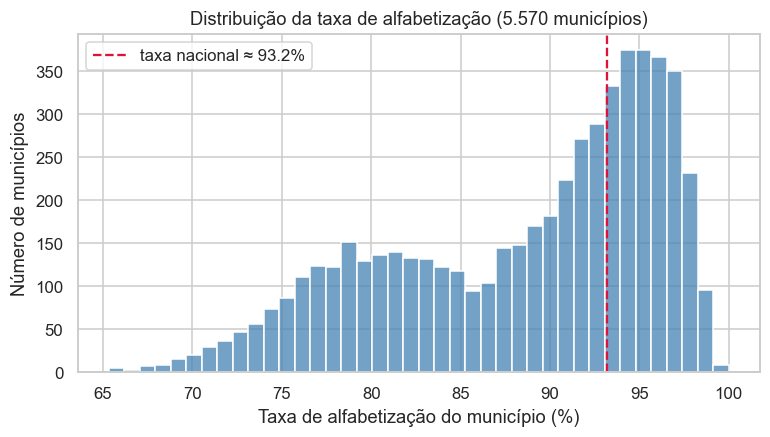

In [5]:
# .describe() devolve estatisticas-resumo (contagem, media, desvio, min, quartis, max).
# Multiplicamos por 100 para ler em porcentagem e arredondamos para 1 casa.
print("Distribuição da taxa de alfabetização entre os municípios:")
print((taxa_alf.describe() * 100).round(1))

plt.figure(figsize=(8, 4))                                   # cria a figura com tamanho (larg, alt) em polegadas
sns.histplot(taxa_alf * 100, bins=40, color="steelblue")     # histograma: distribui as taxas em 40 barras
plt.axvline(taxa_nacional * 100, color="crimson", linestyle="--",   # desenha a linha vertical da taxa nacional
            label=f"taxa nacional ≈ {taxa_nacional:.1%}")
plt.xlabel("Taxa de alfabetização do município (%)")         # rotulo do eixo horizontal
plt.ylabel("Número de municípios")                           # rotulo do eixo vertical
plt.title("Distribuição da taxa de alfabetização (5.570 municípios)")  # titulo
plt.legend()                                                 # exibe a legenda (a linha vermelha)
plt.show()                                                   # renderiza o grafico na tela

## 5. Análise exploratória: o gradiente regional (H1)

Antes de modelar, olhamos como a alfabetização varia por **região** — a primeira hipótese do trabalho.

Taxa média de alfabetização por região:
NM_REGIAO
Nordeste        79.8
Norte           88.4
Centro-Oeste    91.7
Sudeste         92.7
Sul             94.8
Name: taxa_alf, dtype: float64


C:\Users\paulo\AppData\Local\Temp\ipykernel_27088\551920591.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dados, x="NM_REGIAO", y="taxa_alf", order=ordem_reg, palette="viridis")


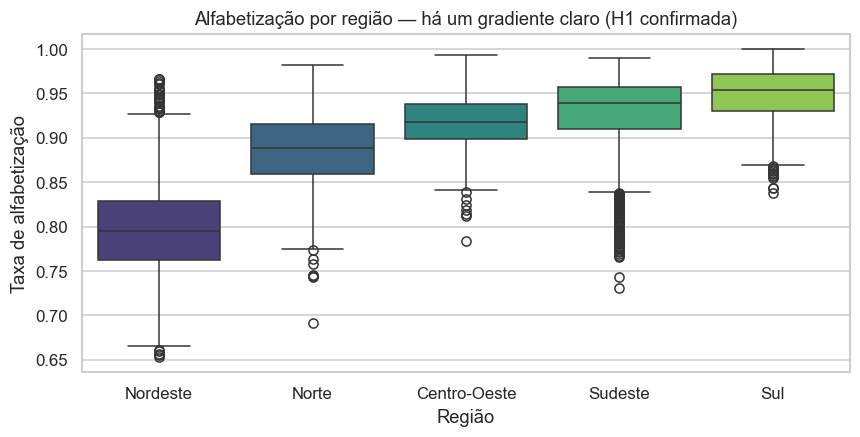

In [6]:
# Montamos um DataFrame de trabalho com o alvo + a identificacao de cada municipio.
dados = pd.DataFrame({
    "CD_MUN":   alfab["CD_MUN"],    # codigo do municipio (chave para juntar tabelas)
    "NM_MUN":   alfab["NM_MUN"],    # nome do municipio
    "taxa_alf": taxa_alf,           # o ALVO que queremos prever
    "pop_15":   pop_15,             # populacao 15+ (sera usada na analise de erros, no fim)
})
# .merge junta 'dados' com colunas da base 'basico' usando o codigo do municipio (CD_MUN).
#   how="inner" mantem apenas os municipios que existem nas duas tabelas.
dados = dados.merge(basico[["CD_MUN", "NM_UF", "NM_REGIAO", "AREA_KM2", "v0001"]],
                    on="CD_MUN", how="inner")

# Define a ordem das regioes pela taxa media (para os graficos sairem do menor ao maior).
#   groupby("NM_REGIAO") agrupa por regiao; ["taxa_alf"].mean() tira a media de cada grupo.
ordem_reg = dados.groupby("NM_REGIAO")["taxa_alf"].mean().sort_values().index

print("Taxa média de alfabetização por região:")
print((dados.groupby("NM_REGIAO")["taxa_alf"].mean().loc[ordem_reg] * 100).round(1))

plt.figure(figsize=(9, 4))
# boxplot: mostra mediana, quartis e outliers da taxa em cada regiao (a "caixa" e o miolo dos dados).
sns.boxplot(data=dados, x="NM_REGIAO", y="taxa_alf", order=ordem_reg, palette="viridis")
plt.ylabel("Taxa de alfabetização"); plt.xlabel("Região")
plt.title("Alfabetização por região — há um gradiente claro (H1 confirmada)")
plt.show()

## 6. Engenharia de variáveis (features)

Vamos prever a taxa de alfabetização a partir de características **estruturais** do município. Usamos
um conjunto **enxuto e 100% interpretável** — cada variável tem significado claro, o que é essencial
para explicar o modelo na apresentação:

| Variável | O que é | Por que pode importar |
|---|---|---|
| `log_pop` | log da população total | porte do município |
| `log_dens` | log da densidade (hab/km²) | proxy de urbanização |
| `share_60mais` | % da população adulta com 60+ anos | coortes mais velhas estudaram menos |
| `share_15a29` | % da população adulta com 15-29 anos | perfil etário jovem (interior/rural) |
| `reg_*` | região (one-hot) | o maior fator estrutural no Brasil |

> **Por que isto NÃO é "trapaça" (vazamento de dados)?** Um erro comum seria prever a taxa de
> alfabetização usando informações que já contêm a resposta. Aqui, `share_60mais` e `share_15a29`
> descrevem a **estrutura etária** (quantas pessoas há em cada idade) — e não **quantas são
> alfabetizadas**. Elas compartilham apenas o *denominador* com o alvo, mas medem coisas diferentes:
> não há identidade matemática entre elas e a taxa. A relação é **aprendida**, não imposta.

In [7]:
# A coluna de area vem como TEXTO com virgula decimal (ex.: "1.234,5"). Convertendo para numero:
basico["AREA_KM2"] = (basico["AREA_KM2"].astype(str)            # garante que e texto
                      .str.replace(",", ".", regex=False)       # troca a virgula decimal por ponto
                      .replace({".": np.nan, "": np.nan})       # trata casos vazios/invalidos como NaN
                      .astype(float))                           # converte o texto limpo para numero real
# Recarrega a coluna AREA_KM2 ja convertida para dentro de 'dados' (substitui a versao texto).
dados = dados.drop(columns="AREA_KM2").merge(
    basico[["CD_MUN", "AREA_KM2"]], on="CD_MUN", how="left")

# Estrutura etaria da populacao 15+ (usa as MESMAS faixas que formam o denominador).
A = alfab[faixas_15mais].apply(pd.to_numeric, errors="coerce")   # as 13 faixas em formato numerico
# share_60mais = (soma das faixas 60-64, 65-69, 70-79, 80+) / populacao 15+
dados["share_60mais"] = A[["V00653", "V00654", "V00655", "V00656"]].sum(axis=1) / pop_15
# share_15a29 = (soma das faixas 15-19, 20-24, 25-29) / populacao 15+
dados["share_15a29"]  = A[["V00644", "V00645", "V00646"]].sum(axis=1) / pop_15

# Porte e urbanizacao. Usamos log porque essas variaveis sao MUITO assimetricas (poucas cidades gigantes).
#   np.log1p(x) = log(1 + x): comprime a cauda e evita log(0) = -infinito quando o valor e zero.
dados["log_pop"]  = np.log1p(dados["v0001"])                     # log da populacao total
densidade = dados["v0001"] / dados["AREA_KM2"].replace(0, np.nan)  # densidade = habitantes / km2
dados["log_dens"] = np.log1p(densidade.fillna(densidade.median()))  # log da densidade (NaN -> mediana)

# Remove eventuais linhas sem alvo e reindexa (deixa os indices 0,1,2,... de novo).
dados = dados.dropna(subset=["taxa_alf"]).reset_index(drop=True)
print("Municípios prontos para modelagem:", len(dados))
# Mostra uma amostra das colunas finais para conferir
dados[["NM_MUN", "NM_UF", "NM_REGIAO", "taxa_alf",
       "log_pop", "log_dens", "share_60mais", "share_15a29"]].head()

Municípios prontos para modelagem: 5570


,NM_MUN,NM_UF,NM_REGIAO,taxa_alf,log_pop,log_dens,share_60mais,share_15a29
0,Alta Floresta D'Oeste,Rondônia,Norte,0.921778,9.975576,1.396593,0.183599,0.283268
1,Ariquemes,Rondônia,Norte,0.942022,11.480753,3.130154,0.147616,0.318631
2,Cabixi,Rondônia,Norte,0.901159,8.585226,1.623579,0.241428,0.218728
3,Cacoal,Rondônia,Norte,0.941649,11.372375,3.174180,0.166022,0.303501
4,Cerejeiras,Rondônia,Norte,0.921127,9.673508,1.903458,0.187606,0.278551


### 6.1 Correlação das variáveis com o alvo

Olhar a correlação de cada variável numérica com a taxa ajuda a antecipar o que o modelo vai usar.

Correlação (linear) de cada variável com a taxa de alfabetização:
share_15a29    -0.407
log_pop         0.131
log_dens        0.183
share_60mais    0.256
Name: taxa_alf, dtype: float64


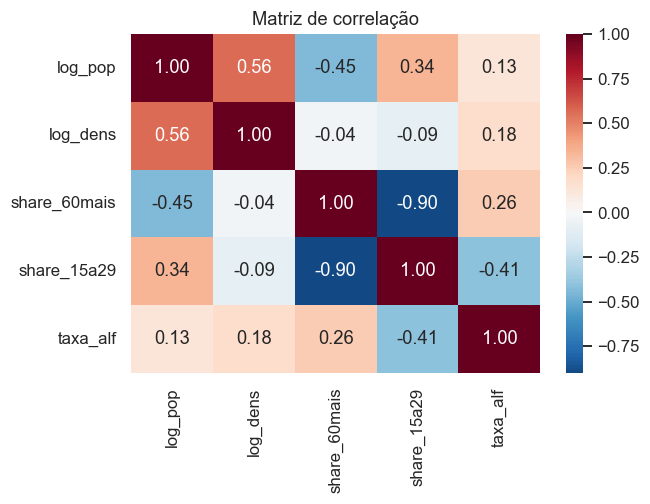

In [8]:
# Lista das variaveis numericas (a regiao entra depois, como one-hot)
num_feats = ["log_pop", "log_dens", "share_60mais", "share_15a29"]

# .corr() calcula a matriz de correlacao; pegamos a coluna do alvo e removemos a correlacao dele consigo mesmo.
corr = dados[num_feats + ["taxa_alf"]].corr()["taxa_alf"].drop("taxa_alf")
print("Correlação (linear) de cada variável com a taxa de alfabetização:")
print(corr.round(3).sort_values())   # ordena da mais negativa para a mais positiva

plt.figure(figsize=(6, 4))
# heatmap desenha a matriz de correlacao com cores; annot=True escreve os numeros nas celulas.
sns.heatmap(dados[num_feats + ["taxa_alf"]].corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0)   # center=0 deixa o branco no zero (azul=+, vermelho=-)
plt.title("Matriz de correlação")
plt.show()

## 7. Pré-processamento: codificação, divisão e padronização

Três passos padrão antes de treinar:

1. **One-hot da região** — transforma a variável de texto "região" em colunas 0/1.
2. **Divisão treino/teste (80/20)** — treinamos em 80% e avaliamos em 20% **nunca vistos**, para medir
   a capacidade de **generalização** (e não de decorar).
3. **Padronização (z-score)** — redes neurais treinam muito melhor quando as variáveis têm a mesma
   escala. O `StandardScaler` é **ajustado só no treino** e depois aplicado no teste, evitando
   vazamento de informação do teste para o treino.

In [9]:
# 1) Monta a matriz de features X: as numericas + a regiao convertida em one-hot (colunas 0/1).
#    pd.get_dummies cria uma coluna por regiao (reg_Norte, reg_Sul, ...). .astype(float) uniformiza o tipo.
X = pd.concat([dados[num_feats],
               pd.get_dummies(dados["NM_REGIAO"], prefix="reg")], axis=1).astype(float)
y = dados["taxa_alf"].values    # o alvo como vetor numpy
feat_names = list(X.columns)    # guarda os nomes das colunas (para rotular a importancia depois)
print("Features usadas:", feat_names)

# 2) Divide em treino (80%) e teste (20%). Levamos junto 'dados' (d_tr/d_te) para a analise de erros.
#    random_state=SEED faz a divisao ser sempre a mesma (reprodutivel).
X_tr, X_te, y_tr, y_te, d_tr, d_te = train_test_split(
    X, y, dados, test_size=0.20, random_state=SEED)

# 3) Padroniza: o scaler APRENDE media e desvio SO no treino (.fit) ...
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)   # ... aplica a transformacao no treino ...
X_te_s = scaler.transform(X_te)   # ... e aplica os MESMOS numeros no teste (sem reaprender = sem vazar)

print(f"Treino: {X_tr.shape[0]} municípios | Teste: {X_te.shape[0]} municípios")

Features usadas: ['log_pop', 'log_dens', 'share_60mais', 'share_15a29', 'reg_Centro-Oeste', 'reg_Nordeste', 'reg_Norte', 'reg_Sudeste', 'reg_Sul']
Treino: 4456 municípios | Teste: 1114 municípios


## 8. Baselines: o que a rede neural precisa superar

Antes de comemorar qualquer resultado da rede, precisamos de uma **régua**. Comparar contra baselines
é o que separa um trabalho sério de um "rodei um modelo e deu um número":

- **Média (`DummyRegressor`)** — sempre "chuta" a taxa média. É o piso absoluto; R² ≈ 0.
- **Média por região** — prevê para cada município a taxa média da sua região. É um baseline **forte e
  honesto**: responde de forma direta à pergunta *"sua rede não é só a média de 5 regiões?"*. Se os
  modelos não superarem este, não estão aprendendo nada além do óbvio.
- **Regressão Linear** — um modelo simples e forte. Se a rede neural não superar a linear, não há
  motivo para usar a rede.

Usamos três métricas: **MAE** (erro médio absoluto), **RMSE** (penaliza erros grandes) e **R²**
(fração da variância explicada — quanto maior, melhor).

In [10]:
# Funcao auxiliar: treina um modelo no treino padronizado e devolve as 3 metricas no teste.
def avaliar(modelo, nome):
    modelo.fit(X_tr_s, y_tr)               # .fit treina o modelo nos dados de treino
    pred = modelo.predict(X_te_s)          # .predict gera as previsoes no teste
    return {"modelo": nome,
            "MAE":  mean_absolute_error(y_te, pred),          # erro absoluto medio
            "RMSE": mean_squared_error(y_te, pred) ** 0.5,    # raiz do erro quadratico medio
            "R2":   r2_score(y_te, pred)}                     # fracao da variancia explicada

res = []                                                      # lista que vai acumular o placar
res.append(avaliar(DummyRegressor(strategy="mean"), "Média (geral)"))   # baseline 1: media geral

# Baseline 2: a media da taxa POR REGIAO, aprendida no treino.
media_regiao = d_tr.groupby("NM_REGIAO")["taxa_alf"].mean()   # media de cada regiao (so no treino)
pred_reg = d_te["NM_REGIAO"].map(media_regiao).values         # cada municipio do teste recebe a media da sua regiao
res.append({"modelo": "Média por região",
            "MAE":  mean_absolute_error(y_te, pred_reg),
            "RMSE": mean_squared_error(y_te, pred_reg) ** 0.5,
            "R2":   r2_score(y_te, pred_reg)})

res.append(avaliar(LinearRegression(), "Regressão Linear"))  # baseline 3: regressao linear

placar = pd.DataFrame(res).set_index("modelo")               # transforma a lista em tabela
print(placar.round(4))
print("\n→ Mesmo a 'média por região' (R² ~0,69) fica abaixo da linear:")
print("  há muita variação DENTRO de cada região que as outras variáveis capturam.")

                     MAE    RMSE      R2
modelo                                  
Média (geral)     0.0654  0.0769 -0.0006
Média por região  0.0328  0.0431  0.6854
Regressão Linear  0.0281  0.0374  0.7635

→ Mesmo a 'média por região' (R² ~0,69) fica abaixo da linear:
  há muita variação DENTRO de cada região que as outras variáveis capturam.


## 9. A rede neural (MLP / rede densa)

O **MLP (*Multilayer Perceptron*)** é a rede neural clássica para dados tabulares: camadas de
neurônios totalmente conectadas, cada uma aplicando uma transformação linear seguida de uma função de
ativação não-linear (`ReLU`). É essa não-linearidade que permite à rede capturar relações que a
regressão linear não consegue.

### Arquitetura e escolhas

```
entrada (9 variáveis) → Dense(64, ReLU) → Dense(32, ReLU) → saída (1: a taxa)
```

- **Duas camadas ocultas (64 e 32)** — profundidade pequena, suficiente para ~5.500 municípios sem
  overfitting.
- **`alpha=0.1` (regularização L2)** — penaliza pesos grandes para evitar *overfitting*. A
  regularização **ajudou a estabilizar a generalização** (mostramos isso na seção 10.2, comparando
  vários `alpha` por validação cruzada — sem espiar o teste).
- **`early_stopping`** — separa parte do treino para validação e **para sozinho** quando a validação
  deixa de melhorar, evitando treinar demais.

In [11]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # duas camadas ocultas, com 64 e 32 neuronios
    activation="relu",             # funcao de ativacao ReLU (introduz a nao-linearidade)
    solver="adam",                 # algoritmo de otimizacao (ajusta os pesos da rede)
    alpha=0.1,                     # regularizacao L2 (penaliza pesos grandes -> menos overfitting)
    max_iter=2000,                 # numero maximo de epocas (passagens pelos dados)
    early_stopping=True,           # para sozinho quando a validacao interna deixa de melhorar
    n_iter_no_change=25,           # quantas epocas sem melhora ele tolera antes de parar
    random_state=SEED,             # semente fixa (reprodutibilidade)
)
mlp.fit(X_tr_s, y_tr)              # treina a rede nos dados de treino padronizados
# mlp.n_iter_ guarda em quantas epocas a rede parou (gracas ao early stopping)
print(f"Rede treinada. Convergiu em {mlp.n_iter_} épocas (early stopping).")

Rede treinada. Convergiu em 117 épocas (early stopping).


### 9.1 Curva de aprendizado

Acompanhar treino e validação ao longo das épocas mostra se a rede está aprendendo de forma saudável
(sem decorar).

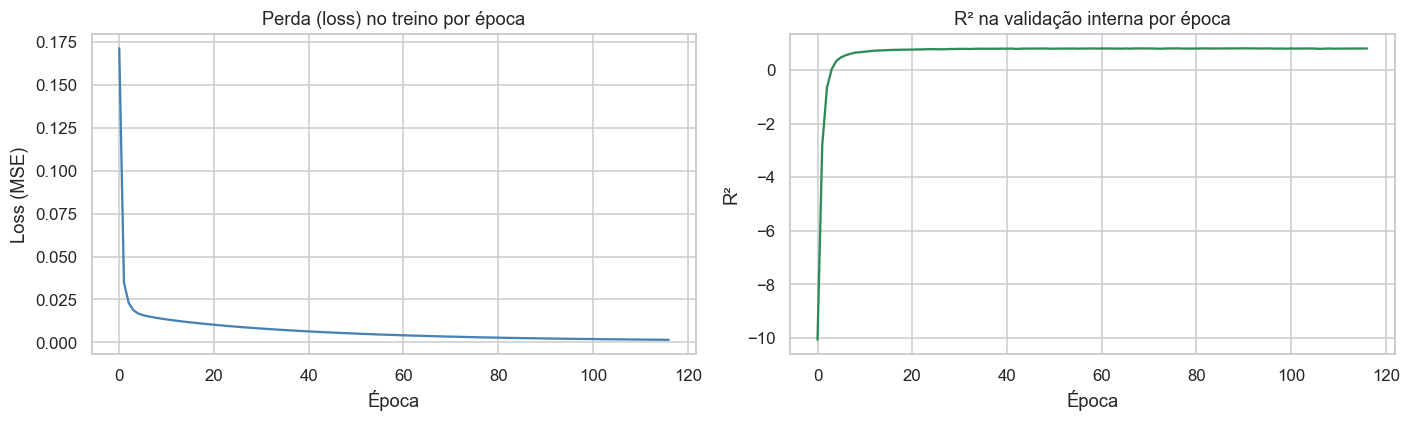

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))    # cria 2 graficos lado a lado

axes[0].plot(mlp.loss_curve_, color="steelblue")   # loss_curve_ = perda no treino em cada epoca
axes[0].set_title("Perda (loss) no treino por época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss (MSE)")

axes[1].plot(mlp.validation_scores_, color="seagreen")  # validation_scores_ = R2 na validacao interna
axes[1].set_title("R² na validação interna por época")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("R²")
plt.tight_layout()   # ajusta os espacamentos para nao sobrepor
plt.show()

## 10. Avaliação: a rede supera os baselines? (H2 e H3)

                      MAE    RMSE      R2
modelo                                   
Média (geral)      0.0654  0.0769 -0.0006
Média por região   0.0328  0.0431  0.6854
Regressão Linear   0.0281  0.0374  0.7635
MLP (rede neural)  0.0257  0.0343  0.8009


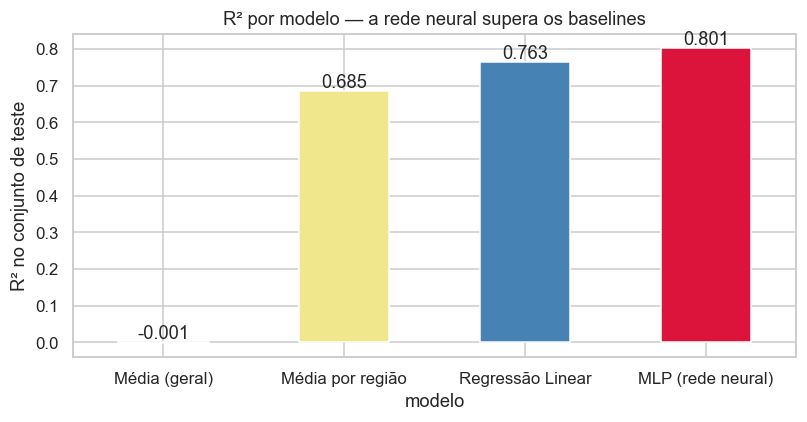

In [13]:
res.append(avaliar(mlp, "MLP (rede neural)"))   # adiciona a MLP ao placar (mesma funcao dos baselines)
placar = pd.DataFrame(res).set_index("modelo")  # refaz a tabela agora com 4 modelos
print(placar.round(4))

# Grafico de barras do R2 de cada modelo (uma cor por modelo).
ax = placar["R2"].plot(kind="bar", color=["lightgray", "khaki", "steelblue", "crimson"],
                       figsize=(7.5, 4), edgecolor="white")
ax.set_ylabel("R² no conjunto de teste")
ax.set_title("R² por modelo — a rede neural supera os baselines")
plt.xticks(rotation=0)                           # mantem os nomes na horizontal
for i, v in enumerate(placar["R2"]):             # escreve o valor de R2 em cima de cada barra
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

### 10.1 Validação cruzada (resultado robusto)

Um único split treino/teste pode dar sorte ou azar. A **validação cruzada 5-fold** treina e testa o
modelo 5 vezes em partições diferentes e reporta a média ± desvio — uma medida bem mais confiável.

In [14]:
# KFold define 5 particoes ("folds"); shuffle embaralha antes de dividir.
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_r2(modelo):
    # make_pipeline encadeia o scaler + o modelo: assim o StandardScaler e re-ajustado DENTRO de
    # cada fold, usando so o treino daquele fold (evita vazamento na validacao cruzada).
    pipe = make_pipeline(StandardScaler(), modelo)
    # cross_val_score treina/testa o pipe nos 5 folds e devolve os 5 valores de R2.
    return cross_val_score(pipe, X, y, cv=kf, scoring="r2")

cv_lin = cv_r2(LinearRegression())   # R2 da linear nos 5 folds
cv_mlp = cv_r2(MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, max_iter=2000,
                            early_stopping=True, n_iter_no_change=25, random_state=SEED))  # da MLP
print(f"R² (5-fold) — Regressão Linear: {cv_lin.mean():.3f} ± {cv_lin.std():.3f}")  # media ± desvio
print(f"R² (5-fold) — MLP:             {cv_mlp.mean():.3f} ± {cv_mlp.std():.3f}")
print("\n→ A rede neural supera a linear de forma consistente (H3 confirmada).")

R² (5-fold) — Regressão Linear: 0.754 ± 0.015
R² (5-fold) — MLP:             0.793 ± 0.015

→ A rede neural supera a linear de forma consistente (H3 confirmada).


### 10.2 O papel da regularização (α)

Afirmar que "a regularização ajuda" exige prova. A célula abaixo compara vários valores de `alpha`
**por validação cruzada** — nunca pelo teste (escolher hiperparâmetro olhando o teste seria trapaça).

In [15]:
print("R² (validação cruzada 5-fold) para diferentes valores de alpha (regularização L2):")
for a in [0.0001, 0.01, 0.1, 1.0]:                 # testa 4 niveis de regularizacao
    pipe = make_pipeline(StandardScaler(),         # mesmo pipeline scaler + rede
                         MLPRegressor(hidden_layer_sizes=(64, 32), alpha=a, max_iter=2000,
                                      early_stopping=True, n_iter_no_change=25, random_state=SEED))
    s = cross_val_score(pipe, X, y, cv=kf, scoring="r2")   # R2 nos 5 folds para esse alpha
    print(f"  alpha = {a:<8}: R² = {s.mean():.3f} ± {s.std():.3f}")
print("\n→ Sem regularização (alpha muito baixo) a rede generaliza pior; com regularização ela")
print("  melhora e fica estável. Por isso usamos um alpha nessa faixa — escolhido por validação.")

R² (validação cruzada 5-fold) para diferentes valores de alpha (regularização L2):


  alpha = 0.0001  : R² = 0.781 ± 0.020


  alpha = 0.01    : R² = 0.798 ± 0.014


  alpha = 0.1     : R² = 0.793 ± 0.015


  alpha = 1.0     : R² = 0.775 ± 0.013

→ Sem regularização (alpha muito baixo) a rede generaliza pior; com regularização ela
  melhora e fica estável. Por isso usamos um alpha nessa faixa — escolhido por validação.


### 10.3 Valores reais × previstos

Se o modelo fosse perfeito, todos os pontos cairiam sobre a diagonal.

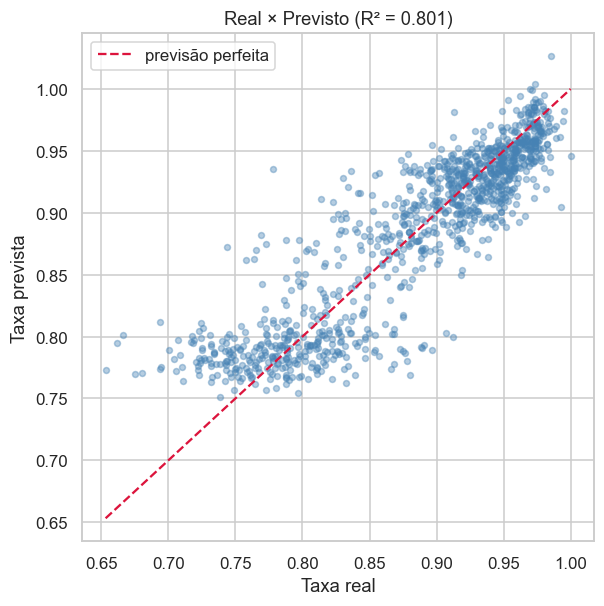

In [16]:
pred_te = mlp.predict(X_te_s)          # previsoes da rede no conjunto de teste

plt.figure(figsize=(6, 6))
plt.scatter(y_te, pred_te, alpha=0.4, s=15, color="steelblue")   # cada ponto = um municipio (real x previsto)
lims = [y_te.min(), y_te.max()]                                  # limites para desenhar a diagonal
plt.plot(lims, lims, "--", color="crimson", label="previsão perfeita")  # linha y=x (previsao ideal)
plt.xlabel("Taxa real")
plt.ylabel("Taxa prevista")
plt.title(f"Real × Previsto (R² = {r2_score(y_te, pred_te):.3f})")
plt.legend()
plt.show()

## 11. Interpretação: quais fatores explicam a alfabetização?

Uma rede neural costuma ser uma "caixa-preta". A **importância por permutação** abre essa caixa: ela
embaralha uma variável de cada vez e mede o **quanto o desempenho piora**. Quanto mais piora ao
embaralhar uma variável, mais o modelo dependia dela.

> **Atenção à escala.** Os valores **não** estão na faixa 0–1 do R². Embaralhar uma variável crucial
> (a região) deixa o modelo *pior do que chutar a média* — o R² fica **negativo** — então a "perda"
> pode passar de 1. O que importa aqui é a **ordem relativa**, não o valor absoluto.

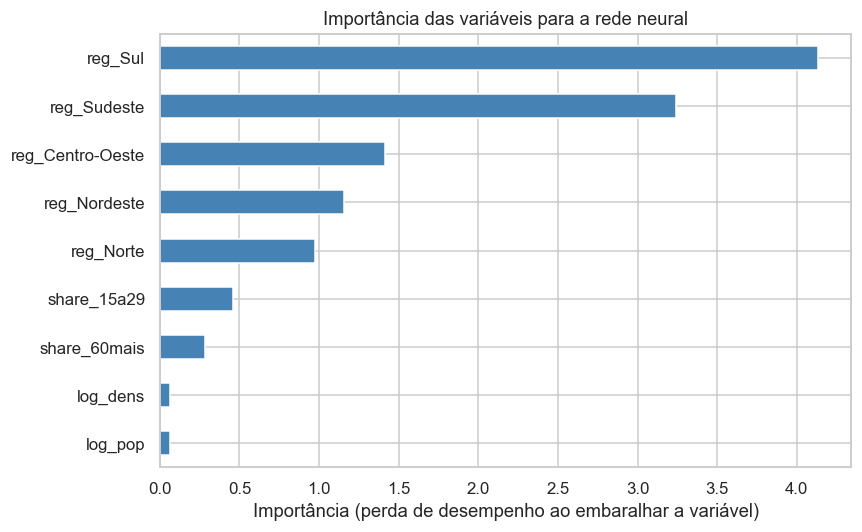

Importância (perda de desempenho ao embaralhar):
reg_Sul             4.1359
reg_Sudeste         3.2440
reg_Centro-Oeste    1.4157
reg_Nordeste        1.1581
reg_Norte           0.9720
share_15a29         0.4576
share_60mais        0.2818
log_dens            0.0668
log_pop             0.0614
dtype: float64


In [17]:
# permutation_importance embaralha cada coluna n_repeats vezes e mede a queda media no R2.
imp = permutation_importance(mlp, X_te_s, y_te, n_repeats=20,
                             random_state=SEED, scoring="r2")
# imp.importances_mean = importancia media de cada variavel; criamos uma Series e ordenamos.
importancias = pd.Series(imp.importances_mean, index=feat_names).sort_values()

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="steelblue", edgecolor="white")   # barras horizontais
plt.xlabel("Importância (perda de desempenho ao embaralhar a variável)")
plt.title("Importância das variáveis para a rede neural")
plt.tight_layout()
plt.show()

print("Importância (perda de desempenho ao embaralhar):")
print(importancias.sort_values(ascending=False).round(4))   # imprime da maior para a menor

**Leitura.** A **região** é, de longe, o fator dominante — confirmando que a alfabetização no Brasil é
um fenômeno fortemente **regional/estrutural**. Em seguida vem a **estrutura etária** (municípios com
população adulta mais jovem tendem a ter taxas menores — um efeito *ecológico*, ligado a regiões mais
pobres e rurais). Porte e densidade contribuem pouco depois de já conhecermos a região.

## 12. Análise de erros e aplicação prática

Onde o modelo erra? E o que os erros revelam? O **resíduo** (real − previsto) tem uma leitura rica:

- **Resíduo positivo** → o município alfabetiza **mais** do que sua estrutura previa (*acima do esperado*).
- **Resíduo negativo** → alfabetiza **menos** do que o esperado (*bolsão* a investigar).

Isso transforma o modelo em uma **ferramenta de triagem regional** — diretamente alinhada ao objetivo
do projeto de *caracterizar perfis e identificar casos atípicos*.

C:\Users\paulo\AppData\Local\Temp\ipykernel_27088\2968897816.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d_te, x="NM_REGIAO", y="residuo",     # residuo por regiao


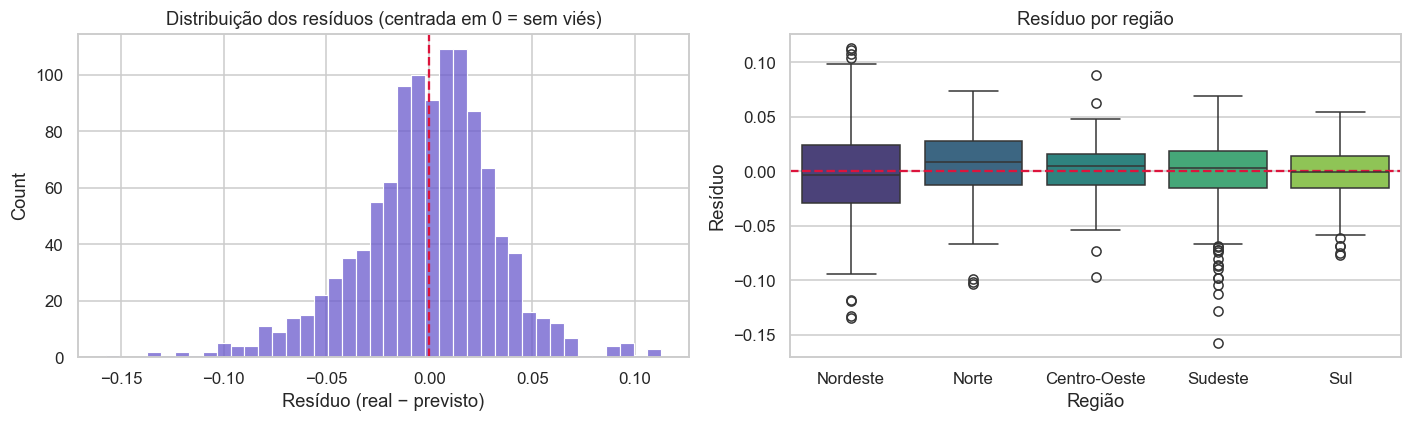

In [18]:
d_te = d_te.copy()                 # copia para nao alterar o DataFrame original
d_te["previsto"] = pred_te         # adiciona a coluna de previsao
d_te["residuo"]  = y_te - pred_te  # residuo = valor real - valor previsto

fig, axes = plt.subplots(1, 2, figsize=(13, 4))   # dois graficos lado a lado
sns.histplot(d_te["residuo"], bins=40, color="slateblue", ax=axes[0])  # distribuicao dos residuos
axes[0].axvline(0, color="crimson", linestyle="--")    # linha no zero (sem erro)
axes[0].set_title("Distribuição dos resíduos (centrada em 0 = sem viés)")
axes[0].set_xlabel("Resíduo (real − previsto)")

sns.boxplot(data=d_te, x="NM_REGIAO", y="residuo",     # residuo por regiao
            order=ordem_reg, palette="viridis", ax=axes[1])
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_title("Resíduo por região")
axes[1].set_xlabel("Região"); axes[1].set_ylabel("Resíduo")
plt.tight_layout()
plt.show()

In [19]:
# Colunas que vamos exibir nas tabelas de municipios atipicos
cols = ["NM_MUN", "NM_UF", "NM_REGIAO", "pop_15", "taxa_alf", "previsto", "residuo"]
view = d_te.copy()
view["pop_15"] = view["pop_15"].astype(int)            # populacao como inteiro (fica mais legivel)
for c in ["taxa_alf", "previsto", "residuo"]:
    view[c] = view[c].round(3)                          # arredonda as 3 colunas numericas

# .nlargest(8, "residuo") pega os 8 maiores residuos (mais acima do esperado)
print("🔼 ACIMA do esperado (alfabetizam mais do que a estrutura previa):")
print(view.nlargest(8, "residuo")[cols].to_string(index=False))

# .nsmallest(8, "residuo") pega os 8 menores residuos (mais abaixo do esperado)
print("\n🔽 ABAIXO do esperado (bolsões a investigar):")
print(view.nsmallest(8, "residuo")[cols].to_string(index=False))

# Leitura mais robusta: filtra so municipios MAIORES (acima da mediana), menos sujeitos a ruido.
mediana_pop = int(view["pop_15"].median())             # corte = mediana da populacao no teste
grandes = view[view["pop_15"] >= mediana_pop]          # mantem so os maiores
print(f"\n🔎 ABAIXO do esperado, apenas municípios MAIORES (pop 15+ ≥ {mediana_pop:,}):")
print(grandes.nsmallest(8, "residuo")[cols].to_string(index=False))

🔼 ACIMA do esperado (alfabetizam mais do que a estrutura previa):
                NM_MUN               NM_UF NM_REGIAO  pop_15  taxa_alf  previsto  residuo
             Palmeiras               Bahia  Nordeste    8030     0.912     0.800    0.113
                 Axixá            Maranhão  Nordeste    8913     0.880     0.769    0.112
            Terra Nova               Bahia  Nordeste    8680     0.897     0.789    0.108
             Guimarães            Maranhão  Nordeste    7978     0.907     0.803    0.104
    São José do Seridó Rio Grande do Norte  Nordeste    3720     0.889     0.791    0.099
Porto Rico do Maranhão            Maranhão  Nordeste    4586     0.878     0.780    0.098
             Itacuruba          Pernambuco  Nordeste    3185     0.890     0.793    0.097
   Carnaúba dos Dantas Rio Grande do Norte  Nordeste    6394     0.888     0.791    0.097

🔽 ABAIXO do esperado (bolsões a investigar):
             NM_MUN        NM_UF NM_REGIAO  pop_15  taxa_alf  previsto  residu

> **Cuidado importante.** Os resíduos extremos tendem a ser de
> **municípios pequenos**, cujas taxas são mais ruidosas (poucos habitantes → mais variabilidade
> amostral). Por isso mostramos também a lista **só com municípios maiores**, que é a leitura mais
> confiável. Tratamos esses casos como **hipóteses a investigar**, não como conclusões — uma triagem
> séria priorizaria municípios maiores com resíduo grande.

## 13. Conclusão

### 13.1 Síntese

Treinamos uma **rede neural densa (MLP)** para prever a **taxa de alfabetização** dos municípios
brasileiros a partir de características estruturais do Censo 2022. Resultados:

1. **H1 ✔** — há um gradiente regional forte (Nordeste ≈ 80% → Sul ≈ 95%).
2. **H2 ✔** — as características estruturais prevêem a taxa com **R² ≈ 0,80** no teste.
3. **H3 ✔** — a rede neural **supera** a regressão linear de forma consistente (validação cruzada),
   capturando relações não-lineares — e a **regularização** ajudou a estabilizar a generalização.

A interpretação mostrou que **região** e **estrutura etária** são os fatores dominantes, e a análise
de resíduos virou uma ferramenta prática para destacar municípios *acima* e *abaixo* do esperado.

### 13.2 Por que MLP e não CNN ou RNN? (uma decisão consciente)

Esta é uma pergunta que vale antecipar:

- **CNN** foi feita para **imagens/grades**, onde pixels vizinhos têm relação espacial. Em uma tabela
  de municípios, as colunas não têm vizinhança espacial — uma CNN aqui seria forçada e injustificável.
- **RNN/LSTM** foi feita para **sequências/séries temporais**. Temos **um único ano (2022)**, sem
  dimensão temporal — não há sequência para a RNN modelar.
- **MLP** é a arquitetura **correta para dados tabulares**. Escolher a rede certa para o tipo de dado
  é mais maduro do que aplicar uma arquitetura "da moda" onde ela não cabe.

### 13.3 Limitações

- **Um único ano (2022)** — não capturamos evolução no tempo.
- **Correlações ecológicas** — as relações são entre *municípios*, não entre *pessoas*; não se pode
  concluir nada sobre indivíduos (falácia ecológica).
- **Municípios pequenos** têm taxas mais ruidosas (poucos habitantes), o que aparece como resíduos
  maiores.
- **Autocorrelação espacial** — municípios vizinhos se parecem. Como o split é aleatório, cidades
  parecidas caem em treino e teste, então o R² mede **interpolação** (dentro do universo de 2022), não
  **extrapolação** para uma região nova. Um `GroupKFold` por UF/região daria um R² menor e mais severo.
- O modelo é **descritivo**, não causal: ele *associa*, não *explica* causas.

## Apêndice — Perguntas e respostas

**1. Por que rede neural e não só regressão linear?**
Porque comparamos as duas: a rede supera a linear no teste e na validação cruzada (R² ≈ 0,80 vs 0,76),
de forma consistente. O ganho é modesto, mas estável (aparece nos 5 folds). Mostramos os baselines
justamente para *provar* que a rede agrega — não usamos a rede "porque sim".

**2. Por que MLP e não CNN/RNN?**
Os dados são tabulares e de um único ano. CNN é para imagens, RNN para sequências; nenhuma se encaixa.
MLP é a escolha correta para tabular (ver seção 13.2).

**3. Como você garante que não há vazamento de dados (data leakage)?**
As features descrevem a *estrutura* do município (região, porte, idade da população), não quantas
pessoas são alfabetizadas. O `StandardScaler` é ajustado só no treino. O teste nunca é visto no treino.

**4. As variáveis de idade não são "circulares" com o alvo?**
Não. Elas compartilham só o denominador (população 15+) com a taxa, mas o numerador é diferente
(quantidade de pessoas por idade vs. quantidade de alfabetizados). Não há identidade matemática.

**5. O que significa o `alpha`, e como você o escolheu?**
É a regularização L2: penaliza pesos grandes para evitar overfitting. A escolha foi por **validação
cruzada** (seção 10.2), nunca espiando o teste — a regularização melhora e estabiliza a generalização.
Não afirmamos que `0.1` é mágico; o passo mais rigoroso seria um `GridSearchCV` só no treino.

**5b. Na importância, como o R² "cai" mais que 1 se ele vai só até 1?**
Os valores não estão na escala 0–1 do R². Ao embaralhar a região, o modelo fica *pior que chutar a
média* (R² negativo), então a perda passa de 1. O que importa é a **ordem relativa**: região ≫ idade ≫
porte/densidade.

**6. O que é o R² e por que ele é a métrica principal?**
É a fração da variância do alvo explicada pelo modelo (1 = perfeito, 0 = igual a chutar a média).
É a métrica natural para regressão e permite comparar modelos diretamente.

**7. Por que padronizar (z-score)?**
Redes neurais e o `adam` convergem muito melhor quando todas as variáveis têm escala parecida.

**8. Sua rede não é só a média por região?**
Não: o baseline "média por região" dá R² ≈ 0,69, contra 0,80 da rede. Há muita variação dentro de
cada região que as variáveis contínuas capturam, e a análise de resíduos só faz sentido porque o
modelo vai além da média regional.

**9. O modelo prova que região *causa* alfabetização?**
Não. É um modelo **descritivo/associativo**, com correlações ecológicas. Não fazemos inferência causal.